In [ ]:
from src import graph_utils
import squidpy as sq 
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import networkx as nx

c:\Users\laure\anaconda3\envs\new_spatial\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\laure\anaconda3\envs\new_spatial\Lib\site-packages\xarray_schema\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


Some example data for which be build the spatial graphs

In [3]:
example_data = np.array([[1,1],[1,0],[0.5,1.5],[0.5,7],[1.5,4],[0,3],[3,3],[3,5],[2,7],[4,9]])

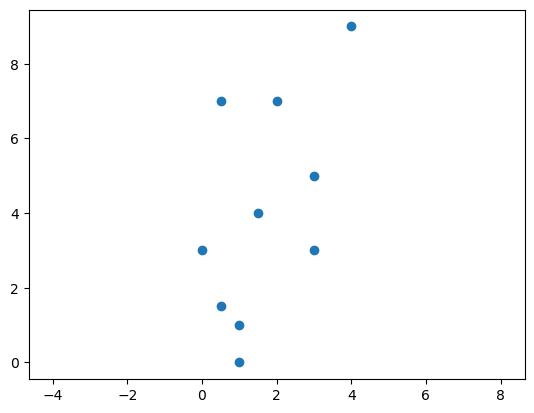

In [4]:
plt.scatter(example_data[:,0], example_data[:,1])
plt.axis('equal')
plt.show()

In [5]:
adata = ad.AnnData(X=np.random.rand(example_data.shape[0], 5))
adata.obsm["spatial"] = example_data

In [6]:
# get adjacency matrices from our function for Delaunay and knn
_, n, tree = graph_utils._get_distances(adata)
_, adj = graph_utils._get_neighbors(adata.obsm["spatial"], tree, "delaunay", n)
_, adj_knn = graph_utils._get_neighbors(adata.obsm["spatial"], tree, "knn", n)

# get adjacency matrix from squidpy for Delaunay triangulation
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)
adj_squidpy = adata.obsp["spatial_connectivities"].toarray().astype(int)

In [7]:
adj_squidpy

array([[0, 1, 1, 0, 0, 0, 1, 0, 0, 0],
       [1, 0, 1, 0, 0, 0, 1, 0, 0, 0],
       [1, 1, 0, 0, 1, 1, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 1, 0, 0, 1, 1],
       [0, 0, 1, 1, 0, 1, 1, 1, 1, 0],
       [0, 0, 1, 1, 1, 0, 0, 0, 0, 0],
       [1, 1, 1, 0, 1, 0, 0, 1, 0, 1],
       [0, 0, 0, 0, 1, 0, 1, 0, 1, 1],
       [0, 0, 0, 1, 1, 0, 0, 1, 0, 1],
       [0, 0, 0, 1, 0, 0, 1, 1, 1, 0]])

In [8]:
adj

array([[0, 1, 1, 0, 0, 0, 1, 0, 0, 0],
       [1, 0, 1, 0, 0, 0, 1, 0, 0, 0],
       [1, 1, 0, 0, 1, 1, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 1, 0, 0, 1, 1],
       [0, 0, 1, 1, 0, 1, 1, 1, 1, 0],
       [0, 0, 1, 1, 1, 0, 0, 0, 0, 0],
       [1, 1, 1, 0, 1, 0, 0, 1, 0, 1],
       [0, 0, 0, 0, 1, 0, 1, 0, 1, 1],
       [0, 0, 0, 1, 1, 0, 0, 1, 0, 1],
       [0, 0, 0, 1, 0, 0, 1, 1, 1, 0]])

In [9]:
np.array_equal(adj, adj_squidpy)

True

squidpy and custom implementation yields identical adjacency! => let's use squidpy's implementation

graph from custom Delaunay implementation:

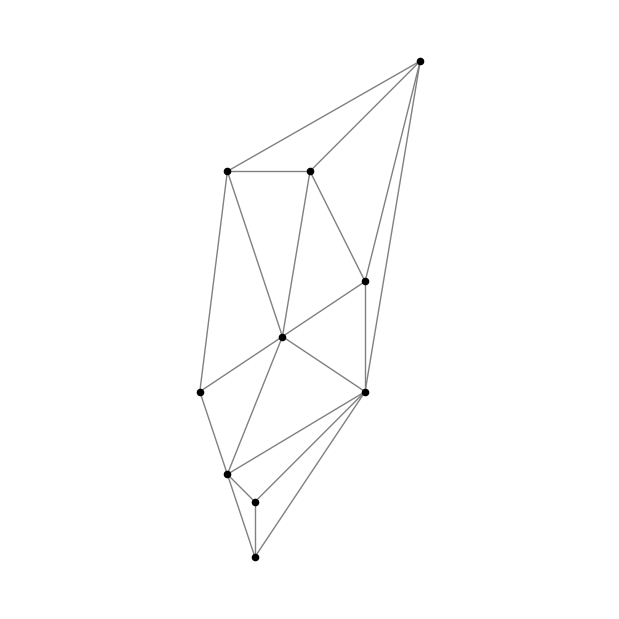

In [10]:
G = nx.from_numpy_array(adj)

# Use spatial positions directly
pos = {i: example_data[i] for i in range(len(example_data))}

# Draw
plt.figure(figsize=(6, 6))
nx.draw(
    G,
    pos,
    with_labels=False,
    node_size=20,
    node_color="black",
    edge_color="gray",
)

plt.axis("equal")   # preserve geometry
plt.show()

graph from squidpy Delaunay implementation:

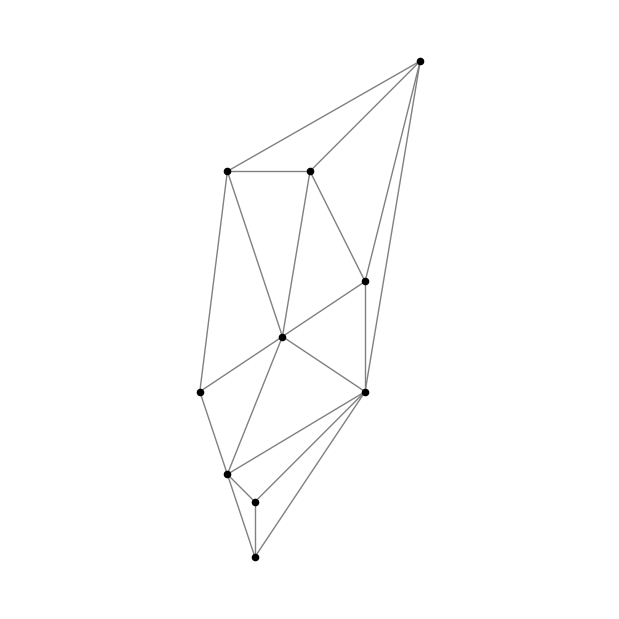

In [11]:
G = nx.from_numpy_array(adj_squidpy)

# Use spatial positions directly
pos = {i: example_data[i] for i in range(len(example_data))}

# Draw
plt.figure(figsize=(6, 6))
nx.draw(
    G,
    pos,
    with_labels=False,
    node_size=20,
    node_color="black",
    edge_color="gray",
)

plt.axis("equal")   # preserve geometry
plt.show()

graph from custom knn implementation

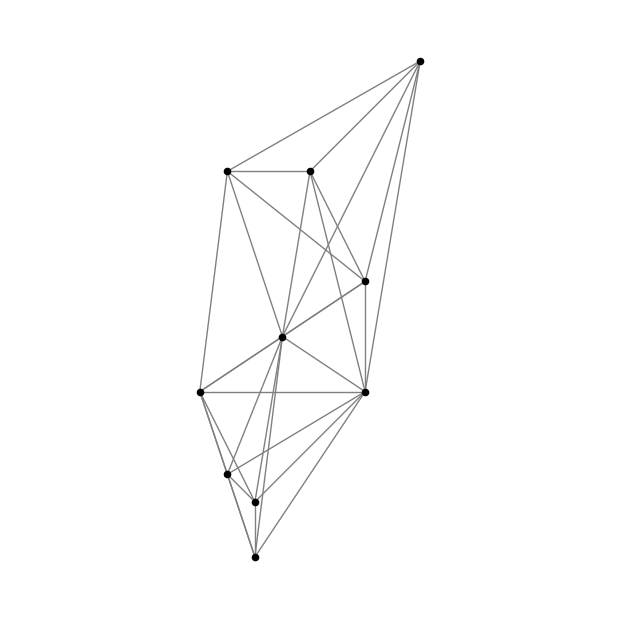

In [12]:
G = nx.from_numpy_array(adj_knn)

# Use spatial positions directly
pos = {i: example_data[i] for i in range(len(example_data))}

# Draw
plt.figure(figsize=(6, 6))
nx.draw(
    G,
    pos,
    with_labels=False,
    node_size=20,
    node_color="black",
    edge_color="gray",
)

plt.axis("equal")   # preserve geometry
plt.show()

Other questions regarding Delaunay triangulation and spatial graph construction in squidpy:

*how is this (the spatial graph) used in the further steps in squidpy?*\
\
There are many key features in squidpy that make use of the spatial graph. Examples are neighborhood enrichment, centrality score, interaction matrices and spatial autocorrelation, which can be found in the graph module. In addition, plotting functions auch as spatial scatter or niche detection methods (which are currently being implemented) make use of the graph.

*how does setting delaunay=True on squidpy integrates with the rest of important parameters such as coord_type or radius or n_neighs?*\
\
When setting delaunay=True, the other parameters which are usually used for knn-graphs, like *radius* and *n_neighs* are ignored. So even if you set e.g. *n_neighs=10* this will not affect the neighborhood constructed via delaunay triangulation (see below). The *coord_type* is only relevant when you have grid-like data e.g. with Visium, where spots are equidistant from each other. In our case we always have generic coordinates. 

Let's see what happens when *delaunay=True* and *n_neighs* or *radius* are provided

In [13]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True, n_neighs=10)
adj_squidpy_new = adata.obsp["spatial_connectivities"].toarray().astype(int)
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True, radius=10)
adj_squidpy_radius = adata.obsp["spatial_connectivities"].toarray().astype(int)

In [14]:
np.array_equal(adj, adj_squidpy_new)

True

In [15]:
np.array_equal(adj_squidpy, adj_squidpy_new)

True

In [16]:
np.array_equal(adj, adj_squidpy_radius)

True

In [17]:
np.array_equal(adj_squidpy, adj_squidpy_radius)

True

In [18]:
np.array_equal(adj_squidpy_new, adj_squidpy_radius)

True